# 03. Missing Data and Causal Inference

Missing data is not only an inconvenience. In causal inference, missingness can change the population, distort treatment-control comparability, hide outcomes, remove confounders, and force new identification assumptions.

A causal analysis has to answer two questions at once:

1. What causal effect are we trying to estimate?
2. Why do the observed data identify that effect when some values are missing?

This notebook treats missingness as a selection process. We will simulate randomized experiments with missing outcomes, compare complete-case analysis with inverse probability weighting and augmented estimators, study missing confounders in observational data, and run a sensitivity analysis for missing-not-at-random outcomes.


## Learning Goals

By the end of this notebook, you should be able to:

- Define missing completely at random, missing at random, and missing not at random.
- Explain why complete-case analysis can change the target population.
- Use missingness diagrams to reason about selection.
- Estimate treatment effects with inverse probability of observation weighting.
- Use outcome regression and augmented IPW for missing outcomes.
- Handle missing confounders with multiple imputation under MAR assumptions.
- Run tipping-point sensitivity analysis for MNAR outcomes.
- Write a missing-data plan for causal projects.


## 1. Setup

We will use pandas, numpy, statsmodels, scipy, seaborn, matplotlib, and Graphviz.


In [1]:
import warnings
warnings.filterwarnings("ignore")

from graphviz import Digraph
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.special import expit
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 90)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


def regression_effect(model, term):
    estimate = model.params[term]
    se = model.bse[term]
    return pd.Series(
        {
            "estimate": estimate,
            "std_error": se,
            "ci_lower": estimate - 1.96 * se,
            "ci_upper": estimate + 1.96 * se,
            "p_value": model.pvalues[term],
        }
    )


def plot_coef_table(table, title, xlabel, reference=0, figsize=(8.5, 4.5)):
    plot_df = table.sort_values("estimate")
    fig, ax = plt.subplots(figsize=figsize)
    ax.errorbar(
        x=plot_df["estimate"],
        y=plot_df.index,
        xerr=[
            plot_df["estimate"] - plot_df["ci_lower"],
            plot_df["ci_upper"] - plot_df["estimate"],
        ],
        fmt="o",
        color="#2b8cbe",
        ecolor="#a6bddb",
        elinewidth=3,
        capsize=4,
    )
    ax.axvline(reference, color="#444444", linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    plt.tight_layout()
    return fig, ax


## 2. Missingness as Selection

Let:

- $A$ be treatment,
- $X$ be pre-treatment covariates,
- $Y$ be the outcome,
- $R$ be an indicator that $Y$ is observed.

The target causal estimand might be:

$$
ATE = E[Y(1) - Y(0)]
$$

in the full eligible population. But if we analyze only observed outcomes, we estimate something closer to:

$$
E[Y(1) - Y(0) \mid R=1]
$$

unless the observed sample represents the full target population in the right way.


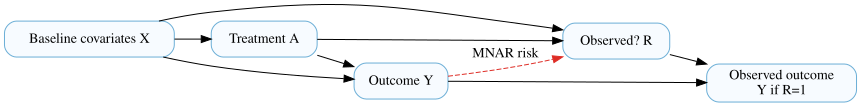

In [2]:
dot = Digraph("missingness_selection", graph_attr={"rankdir": "LR"})
dot.attr("node", shape="box", style="rounded,filled", fillcolor="#f7fbff", color="#6baed6")

dot.node("A", "Treatment A")
dot.node("X", "Baseline covariates X")
dot.node("Y", "Outcome Y")
dot.node("R", "Observed? R")
dot.node("Yobs", "Observed outcome\nY if R=1")

dot.edge("A", "Y")
dot.edge("X", "A")
dot.edge("X", "Y")
dot.edge("A", "R")
dot.edge("X", "R")
dot.edge("Y", "R", style="dashed", color="#de2d26", label="MNAR risk")
dot.edge("Y", "Yobs")
dot.edge("R", "Yobs")

dot


Rubin (1976) formalized conditions under which the missing-data mechanism can be ignored. Little and Rubin (2019) provide a broad modern treatment of missing-data mechanisms and methods.

For causal inference, the key lesson is:

> The missing-data assumption must be compatible with the causal estimand and adjustment strategy.


## 3. Missingness Mechanisms

The classic taxonomy is:


In [3]:
mechanism_table = pd.DataFrame(
    [
        {
            "mechanism": "MCAR",
            "name": "Missing completely at random",
            "condition": "R independent of observed and missing data",
            "causal_risk": "Mostly loss of precision, if truly MCAR.",
        },
        {
            "mechanism": "MAR",
            "name": "Missing at random",
            "condition": "R independent of missing values after conditioning on observed data",
            "causal_risk": "Need correct observed-data adjustment, weighting, or imputation model.",
        },
        {
            "mechanism": "MNAR",
            "name": "Missing not at random",
            "condition": "R depends on unobserved missing values even after conditioning",
            "causal_risk": "Observed data alone generally cannot identify the full-population effect.",
        },
    ]
)

mechanism_table


,mechanism,name,condition,causal_risk
0,MCAR,Missing completely at random,R independent of observed and missing data,"Mostly loss of precision, if truly MCAR."
1,MAR,Missing at random,R independent of missing values after conditio...,"Need correct observed-data adjustment, weighti..."
2,MNAR,Missing not at random,R depends on unobserved missing values even af...,Observed data alone generally cannot identify ...


For missing outcomes, a common MAR condition is:

$$
R \perp Y \mid A, X
$$

This says that among units with the same treatment and observed covariates, whether the outcome is observed does not depend on the outcome value itself.

For inverse probability weighting, we also need positivity:

$$
0 < P(R=1 \mid A, X) < 1
$$

If some subgroup is almost never observed, no method can recover its outcomes without strong extrapolation.


## 4. Simulation 1: Randomized Experiment With Missing Outcomes

We simulate a randomized experiment with a heterogeneous treatment effect:

$$
Y = \mu(X) + A \tau(X) + \epsilon
$$

Then we create three missingness mechanisms:

- MCAR: observation unrelated to variables,
- MAR: observation depends on treatment and baseline covariates,
- MNAR: observation depends on the outcome itself.


In [4]:
def simulate_missing_outcomes(mechanism, seed=10, n=9000):
    rng = np.random.default_rng(seed)
    x = rng.normal(0, 1, size=n)
    baseline_score = rng.normal(0.4 * x, 1, size=n)
    treatment = rng.binomial(1, 0.5, size=n)

    true_tau = 2.0 + 0.65 * x
    y0 = 8.0 + 1.8 * x + 1.2 * baseline_score + rng.normal(0, 1.6, size=n)
    y1 = y0 + true_tau
    y = np.where(treatment == 1, y1, y0)

    if mechanism == "MCAR":
        p_obs = np.repeat(0.72, n)
    elif mechanism == "MAR":
        p_obs = expit(1.10 - 1.25 * x + 0.75 * treatment - 0.65 * treatment * x + 0.25 * baseline_score)
    elif mechanism == "MNAR":
        y_scaled = (y - y.mean()) / y.std()
        p_obs = expit(1.20 - 0.95 * y_scaled + 0.25 * treatment + 0.15 * x)
    else:
        raise ValueError("mechanism must be MCAR, MAR, or MNAR")

    observed = rng.binomial(1, p_obs)
    y_obs = np.where(observed == 1, y, np.nan)

    return pd.DataFrame(
        {
            "mechanism": mechanism,
            "x": x,
            "baseline_score": baseline_score,
            "treatment": treatment,
            "true_tau": true_tau,
            "y0": y0,
            "y1": y1,
            "y": y,
            "observed": observed,
            "p_obs_true": p_obs,
            "y_obs": y_obs,
        }
    )


missing_datasets = {
    mech: simulate_missing_outcomes(mech, seed=100 + i)
    for i, mech in enumerate(["MCAR", "MAR", "MNAR"])
}

df_mar = missing_datasets["MAR"]
df_mar.head()


,mechanism,x,baseline_score,treatment,true_tau,y0,y1,y,observed,p_obs_true,y_obs
0,MAR,-0.790,-0.344,1,1.486,7.156,8.642,8.642,1,0.963,8.642
1,MAR,-2.035,-0.838,0,0.677,6.218,6.895,6.218,1,0.969,6.218
2,MAR,0.603,-0.485,1,2.392,9.263,11.655,11.655,1,0.642,11.655
3,MAR,0.744,1.248,1,2.484,13.755,16.239,16.239,1,0.679,16.239
4,MAR,-0.310,-1.085,1,1.799,4.775,6.574,6.574,1,0.897,6.574


In [5]:
missing_rates = []
for mech, data in missing_datasets.items():
    missing_rates.append(
        {
            "mechanism": mech,
            "observed_rate": data["observed"].mean(),
            "observed_rate_control": data.loc[data["treatment"] == 0, "observed"].mean(),
            "observed_rate_treated": data.loc[data["treatment"] == 1, "observed"].mean(),
            "true_ate": data["true_tau"].mean(),
        }
    )

missing_rates = pd.DataFrame(missing_rates).set_index("mechanism")
missing_rates


,observed_rate,observed_rate_control,observed_rate_treated,true_ate
mechanism,,,,
MCAR,0.724,0.729,0.718,2.014
MAR,0.741,0.710,0.771,1.997
MNAR,0.765,0.790,0.740,1.992


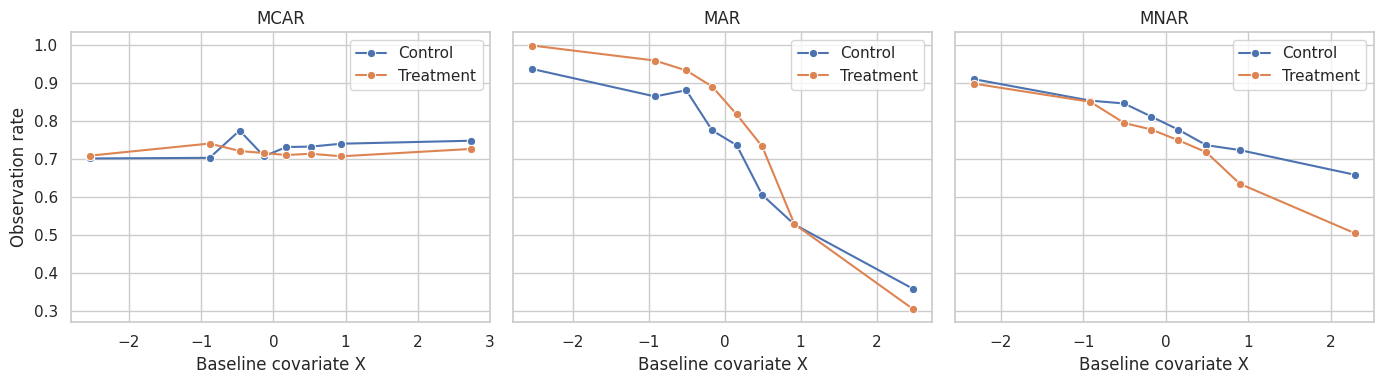

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, (mech, data) in zip(axes, missing_datasets.items()):
    plot_df = (
        data.assign(x_bin=pd.qcut(data["x"], 8, duplicates="drop"))
        .groupby(["x_bin", "treatment"])["observed"]
        .mean()
        .reset_index()
    )
    plot_df["x_mid"] = plot_df["x_bin"].apply(lambda interval: interval.mid).astype(float)
    plot_df["group"] = plot_df["treatment"].map({0: "Control", 1: "Treatment"})
    sns.lineplot(data=plot_df, x="x_mid", y="observed", hue="group", marker="o", ax=ax)
    ax.set_title(mech)
    ax.set_xlabel("Baseline covariate X")
    ax.set_ylabel("Observation rate")
    ax.legend(title="")

plt.tight_layout()
plt.show()


The MAR mechanism creates covariate imbalance among observed units. The MNAR mechanism is worse: observation depends on the outcome itself, which we do not see when missing.


## 5. Complete-Case, IPW, Outcome Regression, and AIPW

We compare several estimators:

- **Complete-case raw:** treatment-control difference among observed outcomes.
- **Outcome regression:** fit an outcome model among observed units and predict both treatment states for all units.
- **IPW:** weight observed outcomes by the inverse probability of being observed.
- **AIPW:** combine outcome regression and observation weighting.

Under MAR, IPW requires a correct observation model. Outcome regression requires a correct outcome model. AIPW is doubly robust in the sense that it can remain consistent if either the observation model or outcome model is correctly specified, under the broader assumptions.

Seaman and White (2013) review IPW for missing data, including stabilized weights, truncation, and augmented approaches.


In [7]:
def weighted_mean(values, weights):
    return np.sum(values * weights) / np.sum(weights)


def estimate_missing_outcome_methods(data):
    observed_data = data.loc[data["observed"] == 1].copy()
    true_ate = data["true_tau"].mean()

    cc_raw = (
        observed_data.loc[observed_data["treatment"] == 1, "y_obs"].mean()
        - observed_data.loc[observed_data["treatment"] == 0, "y_obs"].mean()
    )

    outcome_model = smf.ols(
        "y_obs ~ treatment + x + baseline_score + treatment:x",
        data=observed_data,
    ).fit()
    mu1 = outcome_model.predict(data.assign(treatment=1))
    mu0 = outcome_model.predict(data.assign(treatment=0))
    outcome_regression = np.mean(mu1 - mu0)

    obs_model = smf.logit(
        "observed ~ treatment + x + baseline_score + treatment:x",
        data=data,
    ).fit(disp=False)
    p_obs_hat = np.clip(obs_model.predict(data), 0.03, 0.99)
    observed_data = observed_data.assign(p_obs_hat=p_obs_hat[data["observed"] == 1])
    observed_data["ipw"] = 1 / observed_data["p_obs_hat"]

    ipw_treated = weighted_mean(
        observed_data.loc[observed_data["treatment"] == 1, "y_obs"],
        observed_data.loc[observed_data["treatment"] == 1, "ipw"],
    )
    ipw_control = weighted_mean(
        observed_data.loc[observed_data["treatment"] == 0, "y_obs"],
        observed_data.loc[observed_data["treatment"] == 0, "ipw"],
    )
    ipw = ipw_treated - ipw_control

    p_treated = data["treatment"].mean()
    p_control = 1 - p_treated
    y_obs_filled = data["y_obs"].fillna(0).to_numpy()
    residual1 = y_obs_filled - mu1
    residual0 = y_obs_filled - mu0
    aipw_y1 = np.mean(
        mu1
        + ((data["treatment"] == 1) & (data["observed"] == 1)).astype(float)
        / (p_treated * p_obs_hat)
        * residual1
    )
    aipw_y0 = np.mean(
        mu0
        + ((data["treatment"] == 0) & (data["observed"] == 1)).astype(float)
        / (p_control * p_obs_hat)
        * residual0
    )
    aipw = aipw_y1 - aipw_y0

    return pd.Series(
        {
            "True ATE": true_ate,
            "Complete-case raw": cc_raw,
            "Outcome regression": outcome_regression,
            "IPW": ipw,
            "AIPW": aipw,
        }
    )


missing_estimates = pd.DataFrame(
    {mech: estimate_missing_outcome_methods(data) for mech, data in missing_datasets.items()}
).T

missing_estimates


,True ATE,Complete-case raw,Outcome regression,IPW,AIPW
MCAR,2.014,2.081,2.068,2.108,2.068
MAR,1.997,1.856,2.061,2.140,2.081
MNAR,1.992,1.810,1.963,2.021,1.964


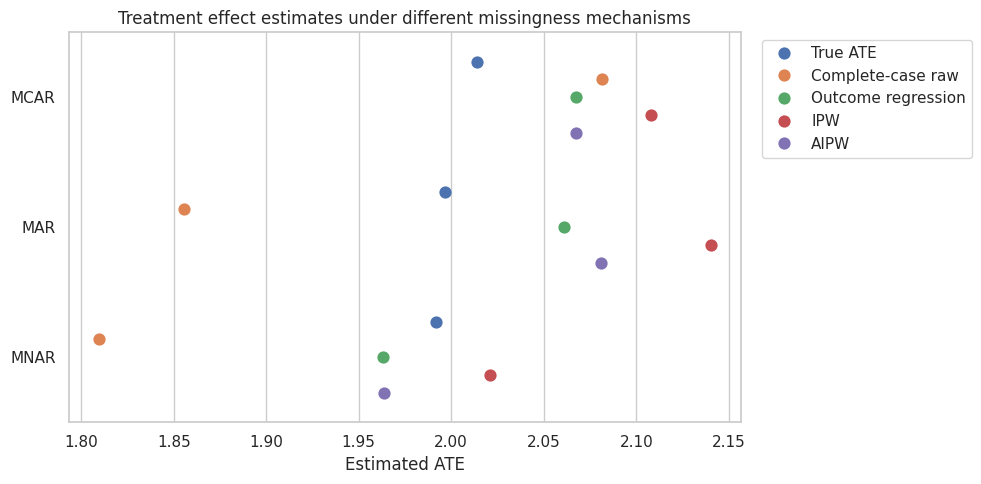

In [8]:
plot_df = (
    missing_estimates.reset_index(names="mechanism")
    .melt(id_vars="mechanism", var_name="method", value_name="estimate")
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.pointplot(
    data=plot_df,
    x="estimate",
    y="mechanism",
    hue="method",
    dodge=0.55,
    join=False,
    ax=ax,
)
ax.set_title("Treatment effect estimates under different missingness mechanisms")
ax.set_xlabel("Estimated ATE")
ax.set_ylabel("")
ax.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


The pattern is the core lesson:

- Under MCAR, complete-case analysis is often close, though less efficient.
- Under MAR, complete-case raw analysis can be biased; outcome regression, IPW, and AIPW can recover the full-population effect if their assumptions and models are adequate.
- Under MNAR, observed-data methods can still be biased because the missingness depends on unobserved outcomes.


## 6. Weight Diagnostics

IPW creates a pseudo-population where observed units represent similar unobserved units. This can fail when observation probabilities are near zero.


In [9]:
obs_model_mar = smf.logit(
    "observed ~ treatment + x + baseline_score + treatment:x",
    data=df_mar,
).fit(disp=False)
df_mar = df_mar.assign(p_obs_hat=np.clip(obs_model_mar.predict(df_mar), 0.03, 0.99))
df_mar = df_mar.assign(ipw=np.where(df_mar["observed"] == 1, 1 / df_mar["p_obs_hat"], np.nan))

weight_summary = df_mar.loc[df_mar["observed"] == 1, "ipw"].describe(percentiles=[0.5, 0.9, 0.95, 0.99])
weight_summary


count   6,668.000
mean        1.351
std         0.644
min         1.010
50%         1.167
90%         1.831
95%         2.275
99%         3.671
max        19.207
Name: ipw, dtype: float64

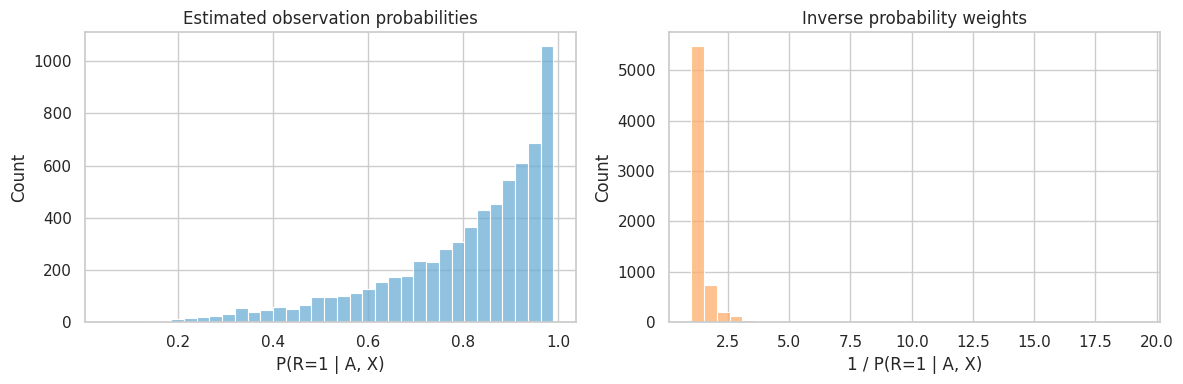

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(
    data=df_mar.loc[df_mar["observed"] == 1],
    x="p_obs_hat",
    bins=35,
    color="#6baed6",
    ax=axes[0],
)
axes[0].set_title("Estimated observation probabilities")
axes[0].set_xlabel("P(R=1 | A, X)")

sns.histplot(
    data=df_mar.loc[df_mar["observed"] == 1],
    x="ipw",
    bins=35,
    color="#fdae6b",
    ax=axes[1],
)
axes[1].set_title("Inverse probability weights")
axes[1].set_xlabel("1 / P(R=1 | A, X)")

plt.tight_layout()
plt.show()


Large weights mean the analysis relies heavily on a small number of observed units. In real projects, report weight distributions and consider stabilized or truncated weights as a sensitivity check.


## 7. Missing Confounders in Observational Causal Inference

Now the missing variable is not the outcome. It is a confounder.

This is common in industry:

- customer income is missing for some users,
- disease severity is missing from some claims records,
- prior usage is missing after logging changes,
- school baseline scores are missing for transfer students.

If a confounder is missing, dropping rows or imputing carelessly can leave confounding bias.


In [11]:
def simulate_missing_confounder(seed=77, n=7500):
    rng = np.random.default_rng(seed)
    z = rng.normal(0, 1, size=n)
    x = rng.normal(0.65 * z, 1, size=n)
    treatment_prob = expit(-0.25 + 1.05 * x + 0.55 * z)
    treatment = rng.binomial(1, treatment_prob)
    true_tau = 1.60
    y = 4.0 + true_tau * treatment + 2.25 * x + 1.10 * z + rng.normal(0, 1.5, size=n)

    y_scaled = (y - y.mean()) / y.std()
    p_x_observed = expit(1.05 - 0.90 * treatment + 0.70 * y_scaled + 0.55 * z)
    x_observed = rng.binomial(1, p_x_observed)
    x_obs = np.where(x_observed == 1, x, np.nan)

    return pd.DataFrame(
        {
            "z": z,
            "x": x,
            "treatment": treatment,
            "y": y,
            "x_observed": x_observed,
            "x_obs": x_obs,
            "p_x_observed": p_x_observed,
            "true_tau": true_tau,
        }
    )


df_xmiss = simulate_missing_confounder()
df_xmiss.head()


,z,x,treatment,y,x_observed,x_obs,p_x_observed,true_tau
0,0.428,-0.253,1,6.158,1,-0.253,0.652,1.600
1,-0.571,0.247,0,6.084,1,0.247,0.724,1.600
2,2.654,3.541,1,16.596,1,3.541,0.974,1.600
3,-1.609,0.295,0,3.490,0,NaN,0.488,1.600
4,0.662,0.662,0,6.411,1,0.662,0.845,1.600


In [12]:
missing_x_summary = (
    df_xmiss.groupby("treatment")
    .agg(
        n=("y", "size"),
        x_observed_rate=("x_observed", "mean"),
        outcome=("y", "mean"),
        z=("z", "mean"),
    )
    .rename(index={0: "Control", 1: "Treated"})
)
missing_x_summary.loc["Difference"] = missing_x_summary.loc["Treated"] - missing_x_summary.loc["Control"]
missing_x_summary


,n,x_observed_rate,outcome,z
treatment,,,,
Control,"4,112.000",0.590,2.341,-0.383
Treated,"3,388.000",0.685,7.649,0.460
Difference,-724.000,0.095,5.308,0.843


The missingness of $X$ depends on observed treatment, outcome, and $Z$. This is MAR if the observed variables are included in the imputation or missingness model.


In [13]:
def fit_treatment_effect(data, formula):
    model = smf.ols(formula, data=data).fit(cov_type="HC1")
    return regression_effect(model, "treatment")


full_data = fit_treatment_effect(df_xmiss, "y ~ treatment + x + z")
unadjusted = fit_treatment_effect(df_xmiss, "y ~ treatment + z")
complete_case = fit_treatment_effect(df_xmiss.loc[df_xmiss["x_observed"] == 1], "y ~ treatment + x_obs + z")

mean_x = df_xmiss["x_obs"].mean()
df_mean_imp = df_xmiss.assign(
    x_mean_imp=df_xmiss["x_obs"].fillna(mean_x),
    x_missing=1 - df_xmiss["x_observed"],
)
mean_indicator = fit_treatment_effect(df_mean_imp, "y ~ treatment + x_mean_imp + x_missing + z")

missing_confounder_results = pd.DataFrame(
    {
        "Full data adjusted": full_data,
        "Unadjusted for missing X": unadjusted,
        "Complete case": complete_case,
        "Mean imputation + missing flag": mean_indicator,
    }
).T

missing_confounder_results


,estimate,std_error,ci_lower,ci_upper,p_value
Full data adjusted,1.654,0.042,1.572,1.736,0.000
Unadjusted for missing X,3.536,0.064,3.411,3.662,0.000
Complete case,1.729,0.052,1.626,1.832,0.000
Mean imputation + missing flag,2.524,0.055,2.417,2.631,0.000


Complete-case and mean-imputation approaches can be misleading. Mean imputation also understates uncertainty because it treats filled-in values as known.

Multiple imputation creates several plausible completed datasets, analyzes each one, and combines estimates using Rubin's rules. Rubin (1987) introduced multiple imputation for nonresponse, and chained-equation implementations such as MICE are widely used in applied work.


In [14]:
def multiple_impute_x(data, m=30, seed=2028):
    rng = np.random.default_rng(seed)
    observed = data.loc[data["x_observed"] == 1].copy()
    imp_model = smf.ols("x_obs ~ treatment + y + z", data=observed).fit()
    sigma = np.sqrt(imp_model.mse_resid)

    coefs = []
    variances = []
    completed_examples = []
    for j in range(m):
        completed = data.copy()
        missing_mask = completed["x_observed"] == 0
        pred_missing = imp_model.predict(completed.loc[missing_mask])
        completed.loc[missing_mask, "x_imp"] = pred_missing + rng.normal(0, sigma, size=missing_mask.sum())
        completed.loc[~missing_mask, "x_imp"] = completed.loc[~missing_mask, "x_obs"]
        model = smf.ols("y ~ treatment + x_imp + z", data=completed).fit()
        coefs.append(model.params["treatment"])
        variances.append(model.bse["treatment"] ** 2)
        if j < 3:
            completed_examples.append(completed["x_imp"].copy())

    coefs = np.array(coefs)
    variances = np.array(variances)
    qbar = coefs.mean()
    ubar = variances.mean()
    between = coefs.var(ddof=1)
    total_var = ubar + (1 + 1 / m) * between
    se = np.sqrt(total_var)
    return pd.Series(
        {
            "estimate": qbar,
            "std_error": se,
            "ci_lower": qbar - 1.96 * se,
            "ci_upper": qbar + 1.96 * se,
            "p_value": np.nan,
            "between_imputation_sd": np.sqrt(between),
        }
    ), completed_examples


mi_result, imputed_examples = multiple_impute_x(df_xmiss)
missing_confounder_results.loc["Multiple imputation"] = mi_result[missing_confounder_results.columns]
missing_confounder_results


,estimate,std_error,ci_lower,ci_upper,p_value
Full data adjusted,1.654,0.042,1.572,1.736,0.000
Unadjusted for missing X,3.536,0.064,3.411,3.662,0.000
Complete case,1.729,0.052,1.626,1.832,0.000
Mean imputation + missing flag,2.524,0.055,2.417,2.631,0.000
Multiple imputation,1.664,0.048,1.571,1.758,NaN


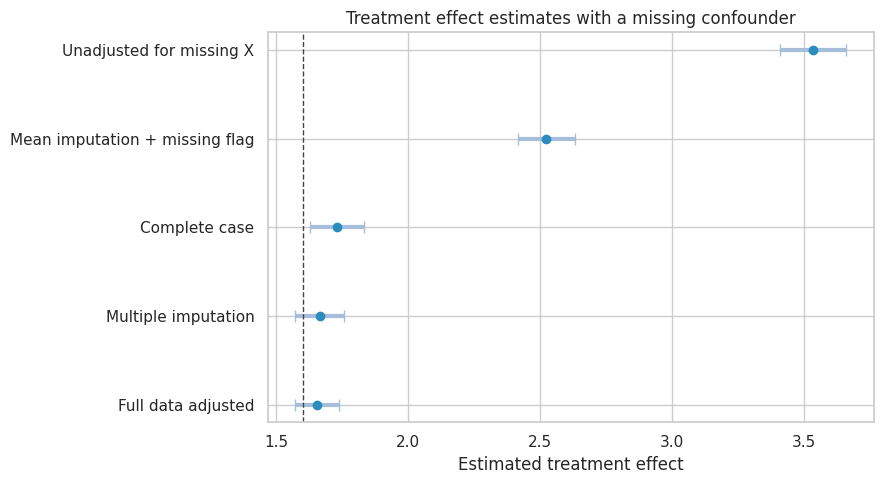

In [15]:
plot_coef_table(
    missing_confounder_results,
    title="Treatment effect estimates with a missing confounder",
    xlabel="Estimated treatment effect",
    reference=df_xmiss["true_tau"].iloc[0],
    figsize=(9, 5),
)
plt.show()


Multiple imputation is not a magic eraser. It is credible when:

- the missingness is plausibly MAR given variables in the imputation model,
- the imputation model includes variables needed for the causal analysis,
- the imputation model respects variable types and relationships,
- the analysis pools uncertainty across imputations,
- sensitivity checks consider departures from MAR.


## 8. Missing Not At Random Sensitivity

When outcomes may be MNAR, observed data alone rarely settle the problem. A practical approach is to ask:

> How different would the missing outcomes need to be to change the conclusion?

We use a delta adjustment. After fitting an MAR-style outcome model, we shift imputed missing treated outcomes by a sensitivity value $\delta$ and recompute the ATE.


In [16]:
df_mnar = missing_datasets["MNAR"].copy()
obs_mnar = df_mnar.loc[df_mnar["observed"] == 1].copy()
mar_outcome_model = smf.ols(
    "y_obs ~ treatment + x + baseline_score + treatment:x",
    data=obs_mnar,
).fit()

df_mnar = df_mnar.assign(y_hat=mar_outcome_model.predict(df_mnar))

delta_rows = []
for delta_treated in np.linspace(-5, 5, 41):
    y_sensitivity = df_mnar["y_obs"].copy()
    missing = df_mnar["observed"] == 0
    y_sensitivity.loc[missing] = df_mnar.loc[missing, "y_hat"]
    treated_missing = missing & (df_mnar["treatment"] == 1)
    y_sensitivity.loc[treated_missing] = y_sensitivity.loc[treated_missing] + delta_treated
    ate_delta = (
        y_sensitivity.loc[df_mnar["treatment"] == 1].mean()
        - y_sensitivity.loc[df_mnar["treatment"] == 0].mean()
    )
    delta_rows.append({"delta_for_missing_treated": delta_treated, "ate": ate_delta})

sensitivity = pd.DataFrame(delta_rows)
sensitivity.head()


,delta_for_missing_treated,ate
0,-5.000,0.734
1,-4.750,0.799
2,-4.500,0.864
3,-4.250,0.929
4,-4.000,0.994


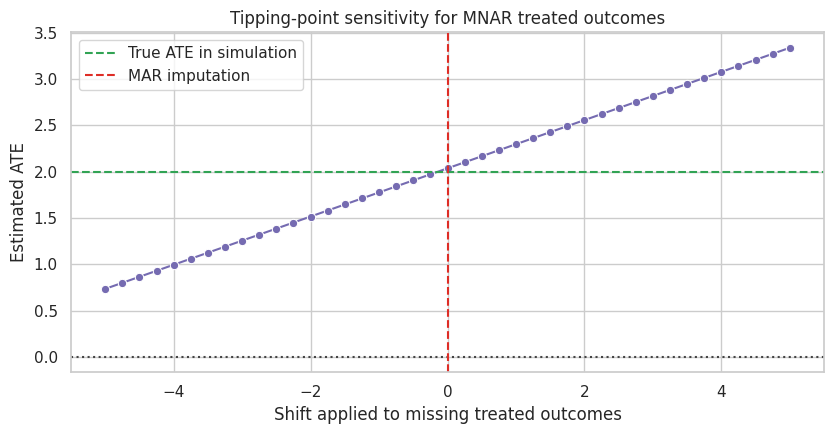

In [17]:
true_mnar_ate = df_mnar["true_tau"].mean()

fig, ax = plt.subplots(figsize=(8.5, 4.5))
sns.lineplot(
    data=sensitivity,
    x="delta_for_missing_treated",
    y="ate",
    marker="o",
    color="#756bb1",
    ax=ax,
)
ax.axhline(true_mnar_ate, color="#31a354", linestyle="--", label="True ATE in simulation")
ax.axhline(0, color="#444444", linestyle=":")
ax.axvline(0, color="#de2d26", linestyle="--", label="MAR imputation")
ax.set_title("Tipping-point sensitivity for MNAR treated outcomes")
ax.set_xlabel("Shift applied to missing treated outcomes")
ax.set_ylabel("Estimated ATE")
ax.legend()
plt.tight_layout()
plt.show()


Sensitivity analysis does not prove which delta is correct. It makes the dependence on unverifiable assumptions visible.


In [18]:
target_effect = 1.5
closest = sensitivity.iloc[(sensitivity["ate"] - target_effect).abs().argmin()]

pd.Series(
    {
        "MAR-style estimate at delta=0": sensitivity.loc[sensitivity["delta_for_missing_treated"] == 0, "ate"].iloc[0],
        "True ATE in simulation": true_mnar_ate,
        "Delta closest to ATE=1.5": closest["delta_for_missing_treated"],
        "ATE at that delta": closest["ate"],
    }
)


MAR-style estimate at delta=0    2.036
True ATE in simulation           1.992
Delta closest to ATE=1.5        -2.000
ATE at that delta                1.515
dtype: float64

A good report would say something like:

> Under MAR, the estimated effect is positive. The conclusion would fall below the practical-significance threshold if missing treated outcomes were about two units lower than predicted by the MAR model.

That is much more useful than pretending MNAR uncertainty does not exist.


## 9. Missingness Plan for Causal Projects

A missing-data plan should be written before the final analysis.


In [19]:
plan = pd.DataFrame(
    [
        {
            "step": "Define the target estimand",
            "question": "Is the effect for all eligible units, observed units, survivors, completers, or another population?",
        },
        {
            "step": "Map missingness",
            "question": "Which outcomes, treatments, confounders, mediators, or follow-up variables are missing?",
        },
        {
            "step": "Draw the selection process",
            "question": "What variables plausibly affect missingness?",
        },
        {
            "step": "State the assumption",
            "question": "MCAR, MAR given observed data, MNAR sensitivity, or principal-stratum estimand?",
        },
        {
            "step": "Choose method",
            "question": "Complete case, IPW, outcome regression, AIPW, multiple imputation, bounds, or sensitivity analysis?",
        },
        {
            "step": "Check diagnostics",
            "question": "Observation rates, covariate balance, weight distributions, imputation diagnostics, and positivity.",
        },
        {
            "step": "Report sensitivity",
            "question": "What violations would change the substantive conclusion?",
        },
    ]
)

plan


,step,question
0,Define the target estimand,"Is the effect for all eligible units, observed..."
1,Map missingness,"Which outcomes, treatments, confounders, media..."
2,Draw the selection process,What variables plausibly affect missingness?
3,State the assumption,"MCAR, MAR given observed data, MNAR sensitivit..."
4,Choose method,"Complete case, IPW, outcome regression, AIPW, ..."
5,Check diagnostics,"Observation rates, covariate balance, weight d..."
6,Report sensitivity,What violations would change the substantive c...


## 10. Decision Memo Example


In [20]:
mar_estimates = missing_estimates.loc["MAR"]
memo = f'''
### Missing Outcome Readout

**Decision question:** estimate the treatment effect in the full randomized population despite missing outcomes.

**Missingness pattern:** outcomes are observed for **{missing_rates.loc["MAR", "observed_rate"]:.1%}** of units in the MAR simulation.
Observation depends on treatment and baseline covariates, so a raw complete-case analysis changes the covariate mix.

**Target estimand:** full-population ATE, not the effect among observed cases only.

**Complete-case raw estimate:** **{mar_estimates["Complete-case raw"]:,.2f}**.

**AIPW estimate:** **{mar_estimates["AIPW"]:,.2f}**, compared with the true simulated ATE of **{mar_estimates["True ATE"]:,.2f}**.

**Main assumption:** conditional on treatment and observed baseline covariates, outcome observation is independent of the missing outcome value.

**Recommendation:** use the adjusted missing-data estimator as the primary MAR analysis, report weight diagnostics, and include an MNAR sensitivity analysis showing how much worse missing outcomes would need to be to change the conclusion.
'''

display(Markdown(memo))



### Missing Outcome Readout

**Decision question:** estimate the treatment effect in the full randomized population despite missing outcomes.

**Missingness pattern:** outcomes are observed for **74.1%** of units in the MAR simulation.
Observation depends on treatment and baseline covariates, so a raw complete-case analysis changes the covariate mix.

**Target estimand:** full-population ATE, not the effect among observed cases only.

**Complete-case raw estimate:** **1.86**.

**AIPW estimate:** **2.08**, compared with the true simulated ATE of **2.00**.

**Main assumption:** conditional on treatment and observed baseline covariates, outcome observation is independent of the missing outcome value.

**Recommendation:** use the adjusted missing-data estimator as the primary MAR analysis, report weight diagnostics, and include an MNAR sensitivity analysis showing how much worse missing outcomes would need to be to change the conclusion.


## 11. Common Failure Modes

- **Treating missingness as a software issue instead of a causal selection issue.**
- **Reporting complete-case results without describing the complete-case population.**
- **Using mean imputation and treating filled values as known.**
- **Imputing a confounder without including the treatment and outcome in the imputation model.**
- **Weighting by observation probabilities without checking positivity or weight tails.**
- **Calling MAR "verified" from data. MAR is an assumption.**
- **Ignoring MNAR sensitivity when missingness plausibly depends on unobserved outcomes.**
- **Changing the estimand from all eligible units to observed units without saying so.**


## 12. Exercises

1. Change the MAR missingness mechanism so high-outcome treated units are more likely to be observed. Which estimators become biased?
2. Truncate IPW weights at the 95th percentile. What happens to bias and variance?
3. Make the outcome model misspecified by removing the treatment-by-X interaction. Compare outcome regression and AIPW.
4. In the missing-confounder simulation, impute $X$ without using $Y$. How does the treatment effect change?
5. Run the MNAR sensitivity analysis with separate deltas for treated and control missing outcomes.
6. Write a missing-data plan for an experiment where long-term retention is missing for users who delete their account.


## 13. Key Takeaways

- Missing data changes causal inference because it changes what is observed and sometimes what is identifiable.
- Complete-case analysis estimates the target effect only under strong conditions.
- Under MAR and positivity, IPW, outcome regression, AIPW, and multiple imputation can recover full-population effects if their models and assumptions are adequate.
- Missing confounders are especially dangerous because they can reintroduce confounding.
- MNAR problems require sensitivity analysis, bounds, or stronger designs because observed data alone cannot usually identify the target effect.
- Every causal analysis with missing data should state the target estimand, missingness assumption, method, diagnostics, and sensitivity checks.


## References

Little, R. J. A., & Rubin, D. B. (2019). *Statistical analysis with missing data* (3rd ed.). Wiley. https://doi.org/10.1002/9781119482260

Rubin, D. B. (1976). Inference and missing data. *Biometrika, 63*(3), 581-592. https://doi.org/10.1093/biomet/63.3.581

Rubin, D. B. (1987). *Multiple imputation for nonresponse in surveys*. Wiley. https://doi.org/10.1002/9780470316696

Seaman, S. R., & White, I. R. (2013). Review of inverse probability weighting for dealing with missing data. *Statistical Methods in Medical Research, 22*(3), 278-295. https://doi.org/10.1177/0962280210395740

van Buuren, S., & Groothuis-Oudshoorn, K. (2011). mice: Multivariate imputation by chained equations in R. *Journal of Statistical Software, 45*(3), 1-67. https://doi.org/10.18637/jss.v045.i03
